In [1]:
import os
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import matplotlib.pyplot as plt
from tqdm import tqdm

In [2]:
# Dataset Class
class MVTecLOCODataset(Dataset):
    def __init__(self, root_dir, split="train", transform=None):
        self.root_dir = root_dir
        self.split = split
        self.transform = transform
        
        # Define the path for the images based on the split
        if self.split == "train":
            self.image_dir = os.path.join(self.root_dir, "train", "good")
        elif self.split == "test":
            self.image_dir = os.path.join(self.root_dir, "test", "good")
        elif self.split == "test2":
            self.image_dir = os.path.join(self.root_dir, "test", "manipulated_front")
        else:
            raise ValueError("Split must be either 'train', 'test', or 'test2'")
        
        # List all image files in the directory
        self.image_files = [f for f in os.listdir(self.image_dir) if f.endswith(".png")]

    def __len__(self):
        return len(self.image_files)

    def __getitem__(self, idx):
        if torch.is_tensor(idx):
            idx = idx.tolist()
        
        # Load the image
        img_name = os.path.join(self.image_dir, self.image_files[idx])
        image = Image.open(img_name).convert("RGB")  # Assuming 3-channel images

        if self.transform:
            image = self.transform(image)

        return image

In [3]:
class CNN_Encoder(nn.Module):
    def __init__(self, embedding_size, img_size, num_channels):
        super(CNN_Encoder, self).__init__()
        self.channel_mult = 64  # Increased from 16 to 64

        # Convolutional layers
        self.conv1 = nn.Sequential(
            nn.Conv2d(num_channels, self.channel_mult, kernel_size=4, stride=2, padding=1),  # 1024 -> 512
            nn.BatchNorm2d(self.channel_mult),
            nn.LeakyReLU(0.2, inplace=True),
        )
        self.conv2 = nn.Sequential(
            nn.Conv2d(self.channel_mult, self.channel_mult * 2, 4, 2, 1),  # 512 -> 256
            nn.BatchNorm2d(self.channel_mult * 2),
            nn.LeakyReLU(0.2, inplace=True),
        )
        self.conv3 = nn.Sequential(
            nn.Conv2d(self.channel_mult * 2, self.channel_mult * 4, 4, 2, 1),  # 256 -> 128
            nn.BatchNorm2d(self.channel_mult * 4),
            nn.LeakyReLU(0.2, inplace=True),
        )
        self.conv4 = nn.Sequential(
            nn.Conv2d(self.channel_mult * 4, self.channel_mult * 8, 4, 2, 1),  # 128 -> 64
            nn.BatchNorm2d(self.channel_mult * 8),
            nn.LeakyReLU(0.2, inplace=True),
        )
        self.conv5 = nn.Sequential(
            nn.Conv2d(self.channel_mult * 8, self.channel_mult * 8, 4, 2, 1),  # 64 -> 32
            nn.BatchNorm2d(self.channel_mult * 8),
            nn.LeakyReLU(0.2, inplace=True),
        )
        self.conv6 = nn.Sequential(
            nn.Conv2d(self.channel_mult * 8, self.channel_mult * 8, 4, 2, 1),  # 32 -> 16
            nn.BatchNorm2d(self.channel_mult * 8),
            nn.LeakyReLU(0.2, inplace=True),
        )
        self.conv7 = nn.Sequential(
            nn.Conv2d(self.channel_mult * 8, self.channel_mult * 8, 4, 2, 1),  # 16 -> 8
            nn.BatchNorm2d(self.channel_mult * 8),
            nn.LeakyReLU(0.2, inplace=True),
        )
        self.conv8 = nn.Sequential(
            nn.Conv2d(self.channel_mult * 8, self.channel_mult * 8, 4, 2, 1),  # 8 -> 4
            nn.BatchNorm2d(self.channel_mult * 8),
            nn.LeakyReLU(0.2, inplace=True),
        )
        self.conv9 = nn.Sequential(
            nn.Conv2d(self.channel_mult * 8, self.channel_mult * 16, 4, 2, 1),  # 4 -> 2
            nn.BatchNorm2d(self.channel_mult * 16),
            nn.LeakyReLU(0.2, inplace=True),
        )
        self.conv10 = nn.Sequential(
            nn.Conv2d(self.channel_mult * 16, self.channel_mult * 16, 4, 2, 1),  # 2 -> 1
            nn.BatchNorm2d(self.channel_mult * 16),
            nn.LeakyReLU(0.2, inplace=True),
        )

        # Fully connected layer to get the embedding
        self.fc = nn.Sequential(
            nn.Linear(self.channel_mult * 16 * 1 * 1, embedding_size),
            nn.BatchNorm1d(embedding_size),
            nn.LeakyReLU(0.2),
        )

    def forward(self, x):
        skips = []  # List to store skip connections
        x = self.conv1(x)
        skips.append(x)
        x = self.conv2(x)
        skips.append(x)
        x = self.conv3(x)
        skips.append(x)
        x = self.conv4(x)
        skips.append(x)
        x = self.conv5(x)
        skips.append(x)
        x = self.conv6(x)
        skips.append(x)
        x = self.conv7(x)
        skips.append(x)
        x = self.conv8(x)
        skips.append(x)
        x = self.conv9(x)
        skips.append(x)
        x = self.conv10(x)
        # No skip connection from the last layer before the embedding
        x = x.view(x.size(0), -1)  # Flatten
        embedding = self.fc(x)
        return embedding, skips


In [4]:
class CNN_Decoder(nn.Module):
    def __init__(self, embedding_size, img_size, num_channels):
        super(CNN_Decoder, self).__init__()
        self.channel_mult = 64

        # Fully connected layer to expand the embedding
        self.fc = nn.Sequential(
            nn.Linear(embedding_size, self.channel_mult * 16 * 1 * 1),
            nn.BatchNorm1d(self.channel_mult * 16 * 1 * 1),
            nn.ReLU(True),
        )

        # Deconvolutional layers with skip connections
        self.deconv1 = nn.Sequential(
            nn.ConvTranspose2d(self.channel_mult * 16, self.channel_mult * 16, 4, 2, 1),
            nn.BatchNorm2d(self.channel_mult * 16),
            nn.ReLU(True),
        )
        self.deconv2 = nn.Sequential(
            nn.ConvTranspose2d(self.channel_mult * 16 * 2, self.channel_mult * 8, 4, 2, 1),
            nn.BatchNorm2d(self.channel_mult * 8),
            nn.ReLU(True),
        )
        self.deconv3 = nn.Sequential(
            nn.ConvTranspose2d(self.channel_mult * 8 * 2, self.channel_mult * 8, 4, 2, 1),
            nn.BatchNorm2d(self.channel_mult * 8),
            nn.ReLU(True),
        )
        self.deconv4 = nn.Sequential(
            nn.ConvTranspose2d(self.channel_mult * 8 * 2, self.channel_mult * 8, 4, 2, 1),
            nn.BatchNorm2d(self.channel_mult * 8),
            nn.ReLU(True),
        )
        self.deconv5 = nn.Sequential(
            nn.ConvTranspose2d(self.channel_mult * 8 * 2, self.channel_mult * 8, 4, 2, 1),
            nn.BatchNorm2d(self.channel_mult * 8),
            nn.ReLU(True),
        )
        # Adjusted deconv6 to output 512 channels
        self.deconv6 = nn.Sequential(
            nn.ConvTranspose2d(self.channel_mult * 8 * 2, self.channel_mult * 8, 4, 2, 1),
            nn.BatchNorm2d(self.channel_mult * 8),
            nn.ReLU(True),
        )
        # Adjusted deconv7 to accept 1024 input channels
        self.deconv7 = nn.Sequential(
            nn.ConvTranspose2d(self.channel_mult * 8 * 2, self.channel_mult * 4, 4, 2, 1),
            nn.BatchNorm2d(self.channel_mult * 4),
            nn.ReLU(True),
        )
        # Adjusted deconv8 to accept 512 input channels
        self.deconv8 = nn.Sequential(
            nn.ConvTranspose2d(self.channel_mult * 4 * 2, self.channel_mult * 2, 4, 2, 1),
            nn.BatchNorm2d(self.channel_mult * 2),
            nn.ReLU(True),
        )
        # Adjusted deconv9 to accept 256 input channels
        self.deconv9 = nn.Sequential(
            nn.ConvTranspose2d(self.channel_mult * 2 * 2, self.channel_mult, 4, 2, 1),
            nn.BatchNorm2d(self.channel_mult),
            nn.ReLU(True),
        )
        # Adjusted deconv10 to accept 128 input channels
        self.deconv10 = nn.Sequential(
            nn.ConvTranspose2d(self.channel_mult * 2, num_channels, 4, 2, 1),
            nn.Tanh(),
        )

    def forward(self, x, skips):
        x = self.fc(x)
        x = x.view(x.size(0), self.channel_mult * 16, 1, 1)

        # Reverse the skips to align with decoder layers
        skips = skips[::-1]

        x = self.deconv1(x)
        x = torch.cat([x, skips[0]], dim=1)
        x = self.deconv2(x)
        x = torch.cat([x, skips[1]], dim=1)
        x = self.deconv3(x)
        x = torch.cat([x, skips[2]], dim=1)
        x = self.deconv4(x)
        x = torch.cat([x, skips[3]], dim=1)
        x = self.deconv5(x)
        x = torch.cat([x, skips[4]], dim=1)
        x = self.deconv6(x)
        x = torch.cat([x, skips[5]], dim=1)
        x = self.deconv7(x)
        x = torch.cat([x, skips[6]], dim=1)
        x = self.deconv8(x)
        x = torch.cat([x, skips[7]], dim=1)
        x = self.deconv9(x)
        x = torch.cat([x, skips[8]], dim=1)
        x = self.deconv10(x)
        return x


In [5]:
class Network(nn.Module):
    def __init__(self, embedding_size, img_size, num_channels):
        super(Network, self).__init__()
        self.encoder = CNN_Encoder(embedding_size, img_size, num_channels)
        self.decoder = CNN_Decoder(embedding_size, img_size, num_channels)

    def forward(self, x):
        z, skips = self.encoder(x)
        reconstructed = self.decoder(z, skips)
        return reconstructed

In [6]:
from torchvision import models

class PerceptualLoss(nn.Module):
    def __init__(self):
        super(PerceptualLoss, self).__init__()
        vgg = models.vgg16(pretrained=True).features[:16]  # Use the first layers of VGG
        self.vgg = vgg.eval()
        for param in self.vgg.parameters():
            param.requires_grad = False

    def forward(self, x, y):
        x_vgg = self.vgg(x)
        y_vgg = self.vgg(y)
        return F.mse_loss(x_vgg, y_vgg)


In [7]:
# Training Function
def train(model, train_loader, optimizer, criterion, device):
    model.train()
    perceptual_loss_fn = PerceptualLoss().to(device)
    
    total_loss = 0
    progress_bar = tqdm(train_loader, desc="Training", unit="batch")

    for images in progress_bar:
        images = images.to(device)

        # Zero the parameter gradients
        optimizer.zero_grad()

        # Forward pass
        # reconstructed = model(images)
        # recon_loss = criterion(reconstructed, images)
        # perceptual_loss = perceptual_loss_fn(reconstructed, images)
        # loss = recon_loss + 0.01 * perceptual_loss  # Weighted combination of losses
        
        reconstructed = model(images)
        loss = criterion(reconstructed, images)
        # perceptual_loss = perceptual_loss_fn(reconstructed, images)
        # loss = recon_loss + 0.01 * perceptual_loss  # Weighted combination of losses


        # Backward pass and optimization
        loss.backward()
        optimizer.step()

        # Accumulate the loss
        total_loss += loss.item()
        progress_bar.set_postfix(loss=loss.item())

    return total_loss / len(train_loader)

In [8]:
# Evaluation Function
def evaluate(model, dataloader, device, threshold=None):
    model.eval()
    all_scores = []

    with torch.no_grad():
        for images in dataloader:
            images = images.to(device)

            # Forward pass
            reconstructed = model(images)

            # Compute per-sample reconstruction error (MSE)
            reconstruction_error = nn.functional.mse_loss(reconstructed, images, reduction='none')
            reconstruction_error = reconstruction_error.view(reconstruction_error.size(0), -1)
            reconstruction_error = reconstruction_error.mean(dim=1)

            # Collect reconstruction scores
            all_scores.extend(reconstruction_error.cpu().numpy())

    # Classify as normal or anomalous based on the threshold
    if threshold is not None:
        predictions = [1 if score > threshold else 0 for score in all_scores]
    else:
        predictions = None

    return all_scores, predictions

# Visualization Function
def visualize(model, dataloader, device, num_images=4, save_path=None, show_error=True):
    model.eval()
    images = next(iter(dataloader))
    images = images.to(device)

    with torch.no_grad():
        reconstructed_image = model(images)

    # Convert to NumPy and transpose dimensions for visualization (batch, height, width, channels)
    images = images.cpu().numpy().transpose(0, 2, 3, 1)
    reconstructed_image = reconstructed_image.cpu().numpy().transpose(0, 2, 3, 1)

    # Rescale images from [-1, 1] to [0, 1]
    images = (images * 0.5) + 0.5
    reconstructed_image = (reconstructed_image * 0.5) + 0.5

    # Clip values to ensure valid image range
    images = np.clip(images, 0, 1)
    reconstructed_image = np.clip(reconstructed_image, 0, 1)

    # Compute reconstruction error if needed
    if show_error:
        reconstruction_error = np.mean((images - reconstructed_image) ** 2, axis=(1, 2, 3))

    # Limit to specified number of images
    n = min(len(images), num_images)
    plt.figure(figsize=(18, 8))
    for i in range(n):
        # Original Image
        ax = plt.subplot(2, n, i + 1)
        plt.imshow(images[i])
        ax.axis('off')
        ax.set_title("Original Image")

        # Reconstructed Image
        ax = plt.subplot(2, n, i + 1 + n)
        plt.imshow(reconstructed_image[i])
        ax.axis('off')
        title = "Reconstructed Image"
        if show_error:
            title += f"\nReconstruction Error: {reconstruction_error[i]:.4f}"
        ax.set_title(title)

    # Save or display the plot
    if save_path:
        plt.savefig(save_path)
        print(f"Visualization saved to {save_path}")
    else:
        plt.show()

    plt.close()

No checkpoint found at 'model_final.pth'


/home/hafiz/my_thesis/seg_recons/venv/lib/python3.12/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/hafiz/my_thesis/seg_recons/venv/lib/python3.12/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Training: 100%|██████████| 40/40 [00:53<00:00,  1.34s/batch, loss=0.0497]


Epoch 2/50, Train Loss: 0.079844, Test Reconstruction Error: 0.0562
Epoch 2/50, Test2 Reconstruction Error: 0.0521


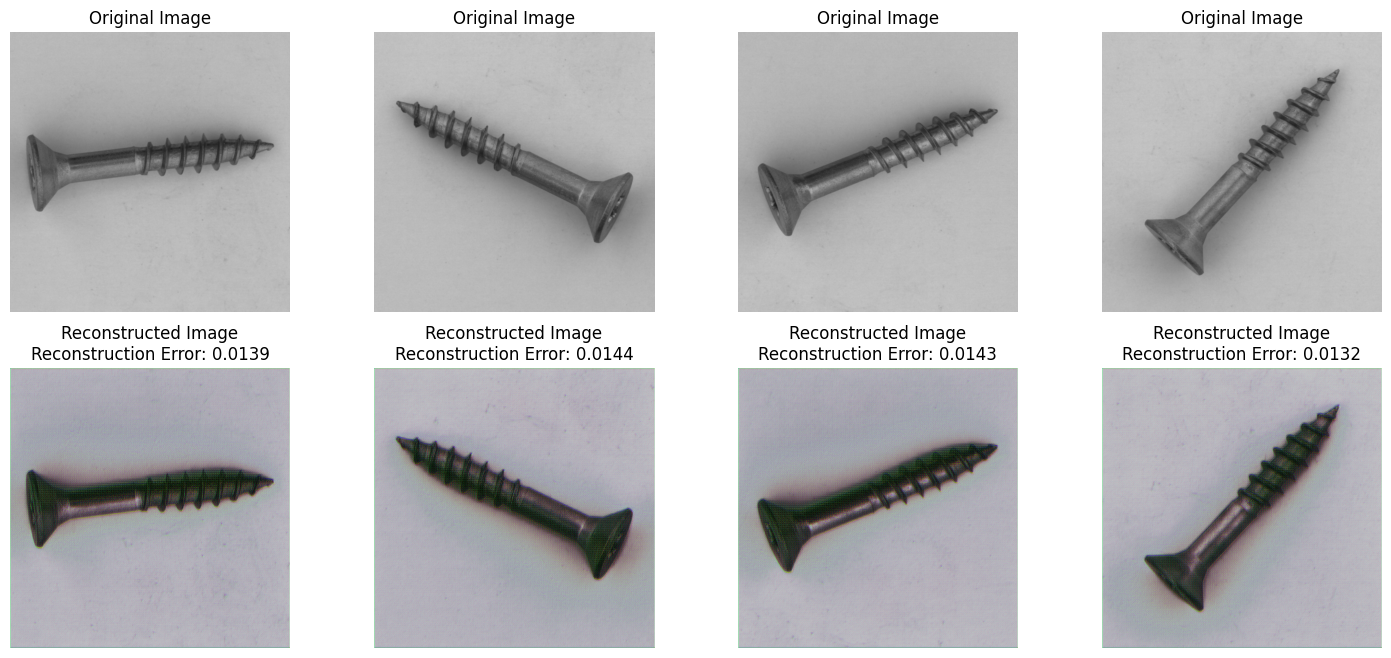

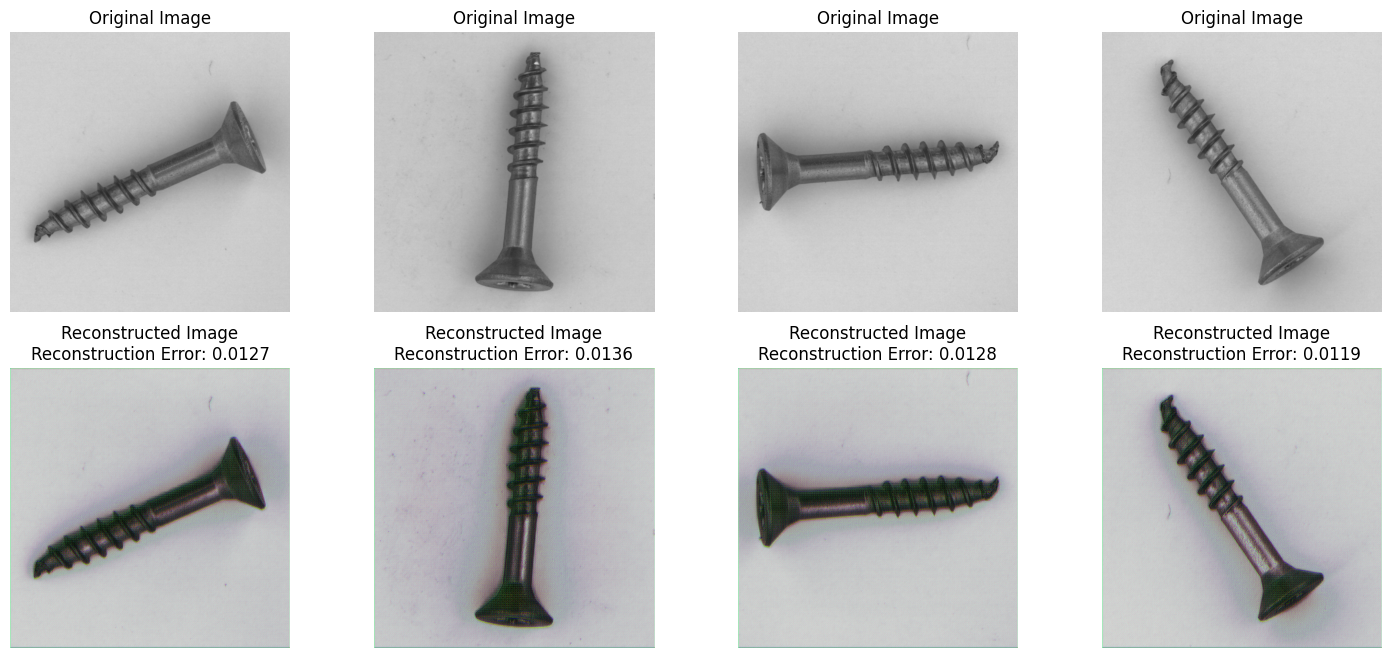

Training: 100%|██████████| 40/40 [01:49<00:00,  2.75s/batch, loss=0.0143]


Epoch 4/50, Train Loss: 0.018486, Test Reconstruction Error: 0.0091
Epoch 4/50, Test2 Reconstruction Error: 0.0083


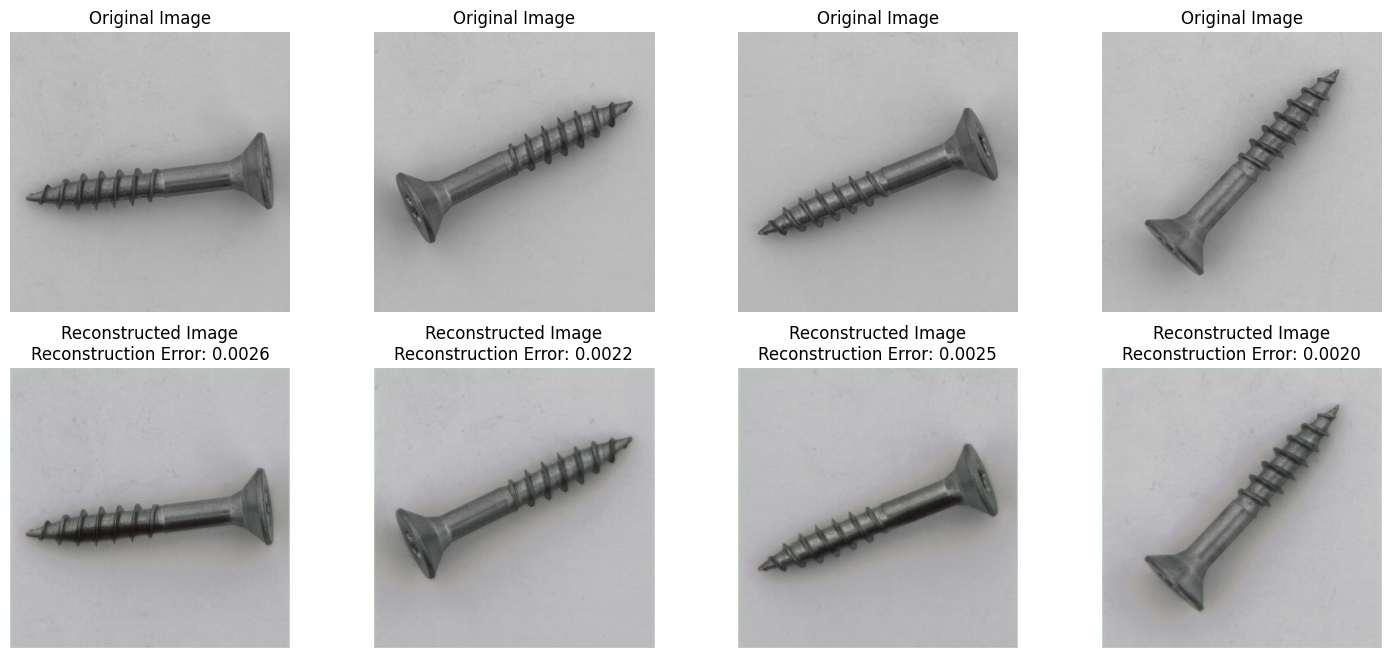

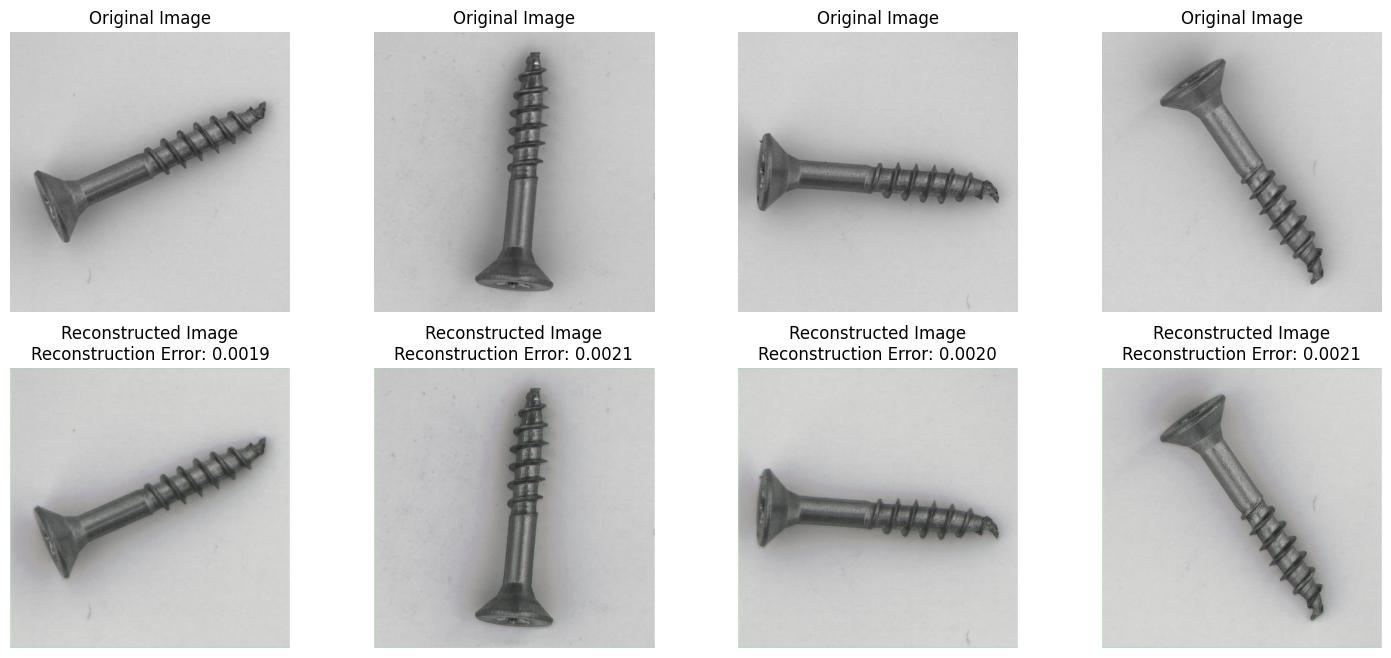

Training:  65%|██████▌   | 26/40 [01:08<00:37,  2.65s/batch, loss=0.00999]


KeyboardInterrupt: 

In [9]:
# Checkpoint Save Function
def save_checkpoint(epoch, model, optimizer, checkpoint_path):
    torch.save({
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
    }, checkpoint_path)
    print(f"Checkpoint saved at '{checkpoint_path}'")

# Checkpoint Load Function
def load_checkpoint(checkpoint_path, model, optimizer, device):
    if os.path.isfile(checkpoint_path):
        print(f"Loading checkpoint from '{checkpoint_path}'")
        checkpoint = torch.load(checkpoint_path, map_location=device)
        model.load_state_dict(checkpoint['model_state_dict'])
        optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
        start_epoch = checkpoint['epoch'] + 1
        print(f"Resuming training from epoch {start_epoch}")
        return start_epoch
    else:
        print(f"No checkpoint found at '{checkpoint_path}'")
        return 0

# Main Function
def main():
    # Hyperparameters
    img_size = 1024  # Adjusted to fit in memory
    num_channels = 3
    batch_size = 8
    num_epochs = 50
    learning_rate = 1e-4
    ROOT_DIR = "/home/hafiz/my_thesis/seg_recons/dataset/screw"
    device = torch.device('cuda:1' if torch.cuda.is_available() else 'cpu')

    # Data Transformations
    transform = transforms.Compose([
        transforms.Resize((img_size, img_size)),
        transforms.RandomHorizontalFlip(),
        transforms.RandomVerticalFlip(),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.5] * num_channels, std=[0.5] * num_channels),
    ])

    # Datasets and Data Loaders
    train_dataset = MVTecLOCODataset(root_dir=ROOT_DIR, split='train', transform=transform)
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

    test_dataset = MVTecLOCODataset(root_dir=ROOT_DIR, split='test', transform=transform)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

    test_dataset2 = MVTecLOCODataset(root_dir=ROOT_DIR, split='test2', transform=transform)
    test_loader2 = DataLoader(test_dataset2, batch_size=batch_size, shuffle=False)

    embedding_size = 128
    model = Network(embedding_size=embedding_size, img_size=img_size, num_channels=num_channels).to(device)

    # Optimizer and Loss Function
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)
    criterion = nn.MSELoss(reduction='mean')

    # Load checkpoint if available
    checkpoint_path = 'model_final.pth'
    start_epoch = load_checkpoint(checkpoint_path, model, optimizer, device)

    # Training Loop
    for epoch in range(start_epoch, num_epochs):
        # Train
        train_loss = train(model, train_loader, optimizer, criterion, device)

        # Evaluate and Visualize every 10 epochs
        if (epoch + 1) % 2 == 0:
            # Evaluate on test set
            all_scores, predictions = evaluate(model, test_loader, device)
            mean_score = np.mean(all_scores) if all_scores else 0
            print(f"Epoch {epoch + 1}/{num_epochs}, Train Loss: {train_loss:.6f}, Test Reconstruction Error: {mean_score:.4f}")

            # Evaluate on test2 set
            all_scores2, predictions2 = evaluate(model, test_loader2, device)
            mean_score2 = np.mean(all_scores2) if all_scores2 else 0
            print(f"Epoch {epoch + 1}/{num_epochs}, Test2 Reconstruction Error: {mean_score2:.4f}")

            # Visualize
            visualize(model, test_loader, device, num_images=4)
            visualize(model, test_loader2, device, num_images=4)

        # Save checkpoint every 25 epochs
        if (epoch + 1) % 25 == 0:
            save_checkpoint(epoch, model, optimizer, f'11_checkpoint_epoch_{epoch + 1}.pth')

    # Save final model
    save_checkpoint(num_epochs, model, optimizer, 'model_final.pth')

if __name__ == "__main__":
    main()